In [1]:
# Cell 1: Gathering our tools (Imports)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve
)

print("Imports successful! Ready for data.")

Imports successful! Ready for data.


In [2]:
# Cell 2: Loading and Formatting the Data

# Load dataset
df = pd.read_csv("german.data", sep=' ', header=None)

# Naming the columns based on the dataset documentation
columns = [
    'status', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings', 'employment', 'installment_rate', 'personal_status',
    'other_debtors', 'residence_since', 'property', 'age',
    'other_installment_plans', 'housing', 'existing_credits',
    'job', 'num_dependents', 'telephone', 'foreign_worker', 'target'
]
df.columns = columns

# Map targets to standard 0 (Good/No Default) and 1 (Bad/Default)
df['target'] = df['target'].map({1: 0, 2: 1})

df.head()

,status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [3]:
# Cell 3: Splitting the Data and Training the Model

# Separate features (X) and the target variable (y) for modeling
X = df.drop('target', axis=1)
y = df['target']

# Dynamically identify categorical columns to apply specific preprocessing
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Define the preprocessing steps
# 'handle_unknown="ignore"' prevents errors if new categories appear in the test set
# 'remainder="passthrough"' ensures numerical columns are kept as-is without being dropped
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# Split data into 80% training and 20% testing sets
# stratify=y ensures the train and test sets maintain the exact same proportion of Good/Bad loans
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Bundle preprocessing and modeling into a single Pipeline
# This guarantees that data transformations are applied consistently and prevents data leakage
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Define the hyperparameter grid to search for optimal model configurations
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 4]
}

print("Training models to find the best parameters...")

# Perform 5-fold cross-validation across all parameter combinations
# n_jobs=-1 utilizes all available CPU cores to drastically speed up training time
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Isolate the highest-performing model from the grid search for future evaluation
best_model = grid_search.best_estimator_
print(f"Done! Best parameters found: {grid_search.best_params_}")

Training models to find the best parameters...
Done! Best parameters found: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 50}


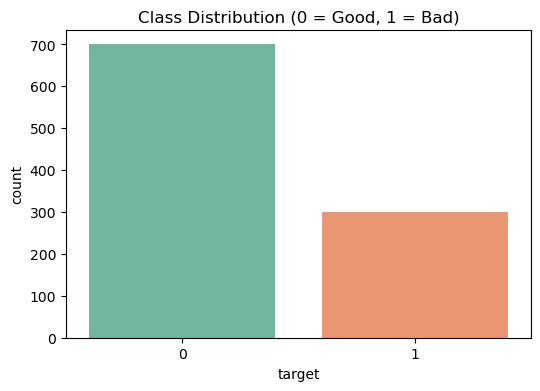

Average CV Accuracy from tuning: 74.88%

--- MODEL EVALUATION (THRESHOLD 0.5) ---
Accuracy:  73.00%
Precision: 56.82%
Recall:    41.67%
F1 Score:  48.08%
ROC-AUC:   76.70%



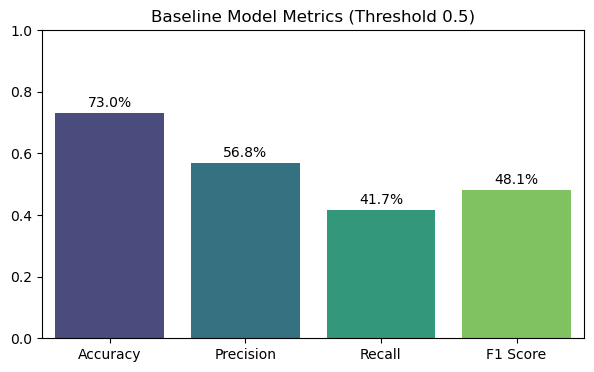

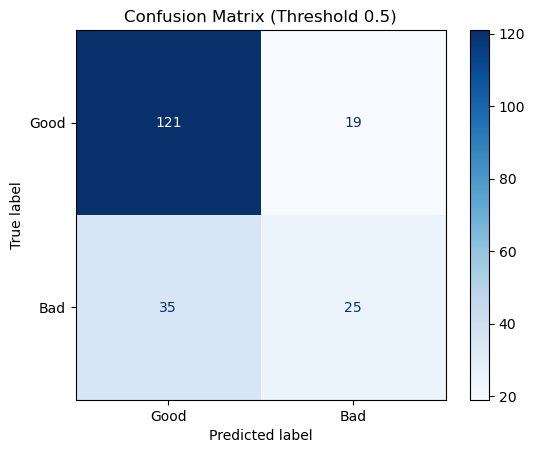

In [13]:
# Cell 4: EDA and Base Evaluation

# 1. Exploratory Data Analysis (EDA) Graph 
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, hue='target', palette='Set2', legend=False)
plt.title("Class Distribution (0 = Good, 1 = Bad)")
plt.show()

# 2. Print Cross-Validation Results from GridSearch
cv_scores = grid_search.cv_results_['mean_test_score']
print(f"Average CV Accuracy from tuning: {np.max(cv_scores) * 100:.2f}%\n")

# 3. Base Predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# 4. Standard Metrics Printout (NOW IN PERCENTAGES!)
print("--- MODEL EVALUATION (THRESHOLD 0.5) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred) * 100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred) * 100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba) * 100:.2f}%\n")

# 5. NEW GRAPH: Visualizing the Base Metrics!
metrics_dict = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
}

plt.figure(figsize=(7, 4))
sns.barplot(x=list(metrics_dict.keys()), y=list(metrics_dict.values()), hue=list(metrics_dict.keys()), palette='viridis', legend=False)
plt.title("Baseline Model Metrics (Threshold 0.5)")
plt.ylim(0, 1)
for index, value in enumerate(metrics_dict.values()):
    plt.text(index, value + 0.02, f"{value*100:.1f}%", ha='center') # Adds percentage labels on top of bars
plt.show()

# 6. Confusion Matrix Visual
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Good", "Bad"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Threshold 0.5)")
plt.show()

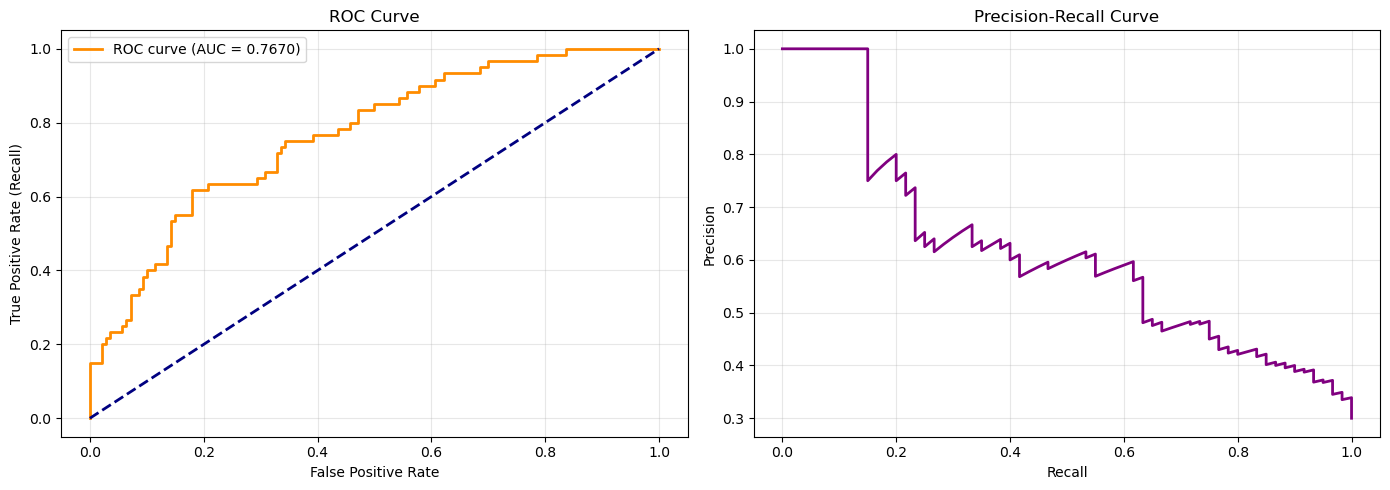

In [14]:
# Cell 5: Advanced Curve Graphs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate (Recall)")
ax1.set_title("ROC Curve")
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
ax2.plot(recall, precision, color='purple', lw=2)
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

--- CUSTOM THRESHOLD EVALUATION (0.3) ---
Accuracy:  67.50%
Precision: 47.06%
Recall:    66.67%
F1 Score:  55.17%

Default Threshold (0.5) Total Cost Penalty: 194
Custom Threshold (0.3) Total Cost Penalty:  145


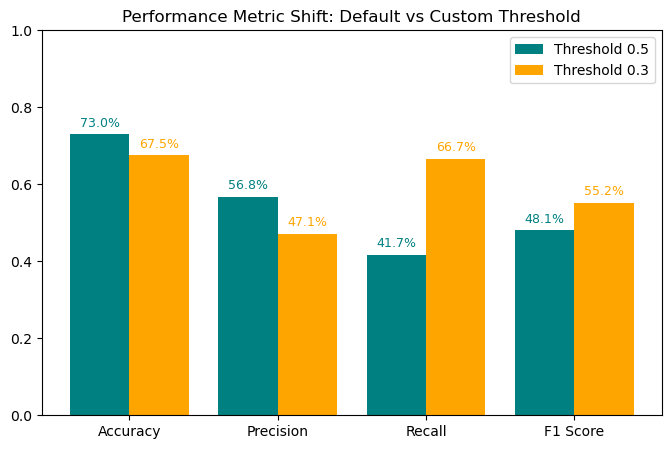

In [8]:
# Cell 6: Threshold Tuning and Cost Evaluation

# Define the cost function based on the assignment documentation
def calculate_cost(y_true, y_pred_classes):
    cm = confusion_matrix(y_true, y_pred_classes)
    bad_loans_given = cm[1][0]  # False Negatives (Missed Bad Loans)
    good_loans_denied = cm[0][1] # False Positives (Incorrectly Denied Good Loans)
    return (bad_loans_given * 5) + (good_loans_denied * 1)

# Shift threshold to 0.3 (Be more aggressive at flagging "Bad" loans)
y_pred_custom = (y_pred_proba > 0.3).astype(int)

# Calculate and Format Metrics for Custom Threshold
accuracy_custom = accuracy_score(y_test, y_pred_custom)
precision_custom = precision_score(y_test, y_pred_custom)
recall_custom = recall_score(y_test, y_pred_custom)
f1_custom = f1_score(y_test, y_pred_custom)

# Calculate Costs
default_cost = calculate_cost(y_test, y_pred)
custom_cost = calculate_cost(y_test, y_pred_custom)

print("--- CUSTOM THRESHOLD EVALUATION (0.3) ---")
# NOW PRINTING PERCENTAGES TO MATCH CELL 4
print(f"Accuracy:  {accuracy_custom * 100:.2f}%")
print(f"Precision: {precision_custom * 100:.2f}%")
print(f"Recall:    {recall_custom * 100:.2f}%")
print(f"F1 Score:  {f1_custom * 100:.2f}%")

print(f"\nDefault Threshold (0.5) Total Cost Penalty: {default_cost}")
print(f"Custom Threshold (0.3) Total Cost Penalty:  {custom_cost}")

# --- Comparison Graphs (Keep as is) ---
labels = ["Accuracy", "Precision", "Recall", "F1 Score"]
metrics_default = [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), 
                   recall_score(y_test, y_pred), f1_score(y_test, y_pred)]
metrics_custom = [accuracy_custom, precision_custom, recall_custom, f1_custom]

x = np.arange(len(labels))
plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, metrics_default, width=0.4, label="Threshold 0.5", color='teal')
plt.bar(x + 0.2, metrics_custom, width=0.4, label="Threshold 0.3", color='orange')
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.title("Performance Metric Shift: Default vs Custom Threshold")
plt.legend()
for index, value in enumerate(metrics_default):
    plt.text(index - 0.2, value + 0.02, f"{value*100:.1f}%", ha='center', fontsize=9, color='teal') 
for index, value in enumerate(metrics_custom):
    plt.text(index + 0.2, value + 0.02, f"{value*100:.1f}%", ha='center', fontsize=9, color='orange') 
plt.show()

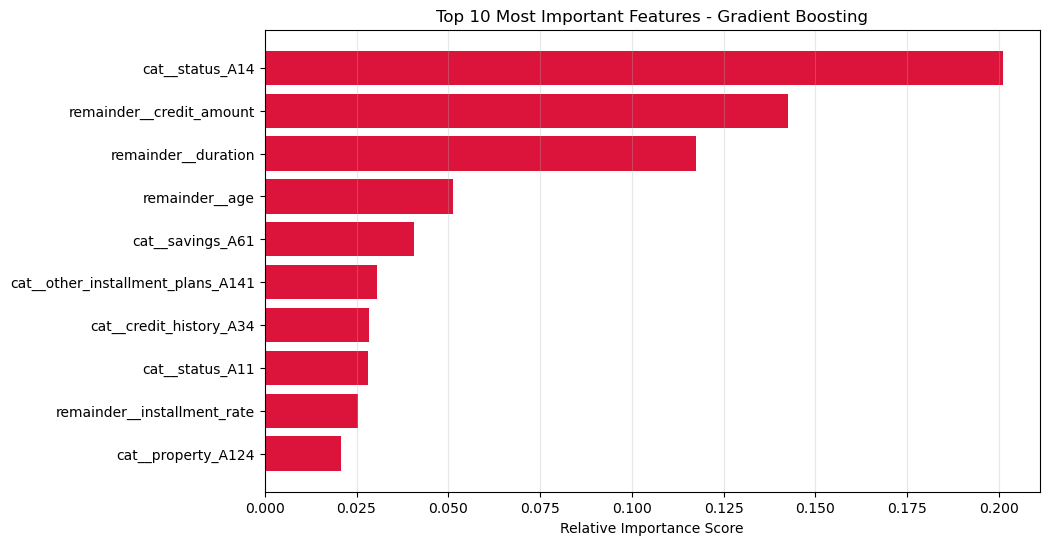

In [9]:
# Cell 7: Feature Importance

# Extract the classifier and preprocessor from the Pipeline
gb_classifier = best_model.named_steps['classifier']
preprocessor = best_model.named_steps['preprocessor']

# Get encoded feature names
feature_names = preprocessor.get_feature_names_out()
importances = gb_classifier.feature_importances_

# Sort and plot
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1], color='crimson')
plt.xlabel('Relative Importance Score')
plt.title('Top 10 Most Important Features - Gradient Boosting')
plt.grid(axis='x', alpha=0.3)
plt.show()